In [27]:
pip install pandas matplotlib scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
data = pd.read_csv('recharge_data.csv')
data.head()

,MonthlyUsage,CustomerType,Complaints,Recharged
0,2669,Postpaid,Yes,Yes
1,1151,Basic,No,Yes
2,1584,Basic,Yes,Yes
3,2693,Postpaid,No,Yes
4,500,Postpaid,Yes,No


In [29]:
print('Columns:',  data.columns.tolist())

print('\nDataset Info: ')
print(data.info())

print(data.describe())

print('\nDataset Completeness:')
print(data.isnull().sum())

print('\nDataset Consistency: ')
print(data.dtypes)

print(data.shape)

Columns: ['MonthlyUsage', 'CustomerType', 'Complaints', 'Recharged']

Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   MonthlyUsage  150 non-null    int64 
 1   CustomerType  150 non-null    object
 2   Complaints    150 non-null    object
 3   Recharged     150 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.8+ KB
None
       MonthlyUsage
count      150.0000
mean      1448.6400
std        825.4999
min        135.0000
25%        801.7500
50%       1368.5000
75%       1884.7500
max       2995.0000

Dataset Completeness:
MonthlyUsage    0
CustomerType    0
Complaints      0
Recharged       0
dtype: int64

Dataset Consistency: 
MonthlyUsage     int64
CustomerType    object
Complaints      object
Recharged       object
dtype: object
(150, 4)


## 33.4.2  Dataset Specification Sheet

| **Field**           | **Details** |
|---------------------|-------------|
| **Dataset Name**    | `recharge_data.csv` (demo dataset) |
| **Description**     | Contains customer behavior data used to demonstrate Data Quality checks including Completeness, Consistency, Accuracy, Bias analysis, and basic feature engineering. |
| **Features**        | `MonthlyUsage`,`CustomerType`,`Complaints` |
| **Target Variable** | *Recharged*(Yes=Recharged) |
| **Number of Rows**  | 150 |
| **Null Handling**   | No missing values detected across any feature |
| **Transformations** | Label encoding applied to `categorical data`; datatype validation performed; value distribution and proportion analysis conducted for `MonthlyUsage`,`CustomerType`,`Complaints` |
| **Owner**           | Vedashree , Taniksha|
| **Last Updated**    | 2026-02-02 |

In [30]:
data['CustomerType'].value_counts(normalize=True)
data['Recharged'].value_counts(normalize=True)

Recharged
Yes    0.7
No     0.3
Name: proportion, dtype: float64

<Axes: >

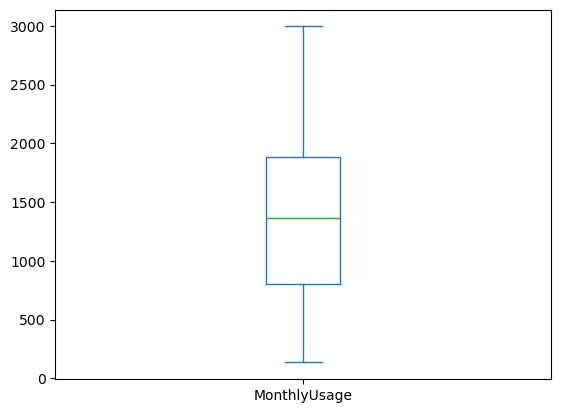

In [31]:
data['MonthlyUsage'].plot(kind='box')

In [32]:

categorical = data.select_dtypes(include= 'object').columns
numerical = data.select_dtypes(exclude= 'object').columns

print("Categorical Features:", list(categorical))
print("Numerical Features:", list(numerical))

Categorical Features: ['CustomerType', 'Complaints', 'Recharged']
Numerical Features: ['MonthlyUsage']


In [33]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['CustomerType']=le.fit_transform(data['CustomerType'])
data['Complaints']=le.fit_transform(data['Complaints'])
data['Recharged']=le.fit_transform(data['Recharged'])

x=data[['MonthlyUsage','CustomerType','Complaints']]
y=data['Recharged']
data


,MonthlyUsage,CustomerType,Complaints,Recharged
0,2669,1,1,1
1,1151,0,0,1
2,1584,0,1,1
3,2693,1,0,1
4,500,1,1,0
...,...,...,...,...
145,1343,2,1,1
146,1540,2,0,1
147,497,4,1,0
148,1283,0,1,1


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score,KFold,StratifiedKFold
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [42]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2
)

kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
scores = cross_val_score(model, x_train, y_train, cv = kf)
print("Accuracy for each fold: ", scores)
print("Average Accuracy:", scores.mean())
model.fit(x_train,y_train)

Accuracy for each fold:  [0.95238095 0.95238095 1.         0.95238095 0.80952381]
Average Accuracy: 0.9333333333333332


DecisionTreeClassifier(max_depth=6, min_samples_leaf=2, min_samples_split=5)

In [43]:
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accuracy:',accuracy_score(y_test,y_pred))
print('confusion Matrix:\n', confusion_matrix(y_test,y_pred))

Accuracy: 0.9777777777777777
confusion Matrix:
 [[13  0]
 [ 1 31]]


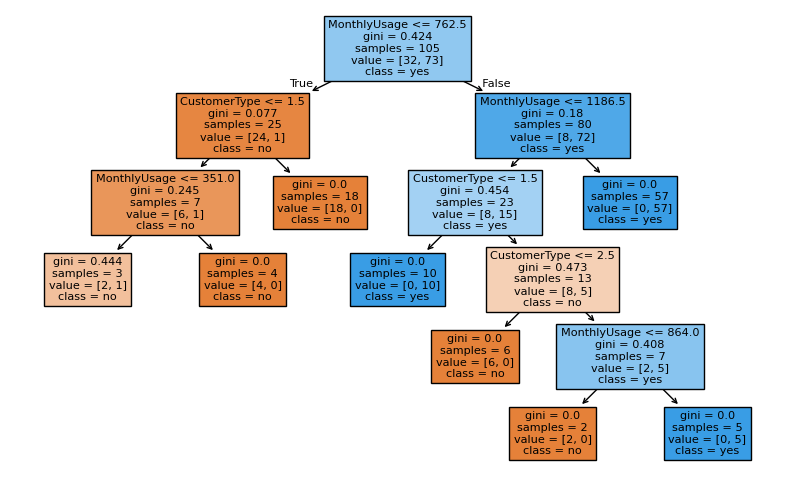

In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(model, feature_names=['MonthlyUsage','CustomerType','Complaints'],class_names=['no','yes'],filled=True)
plt.show()

In [38]:
new_data=[[1130,2,3]]
print('Recharge Prediction:',model.predict(new_data))


Recharge Prediction: [0]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
